# 01. Core: Deep Agent + LangGraph State
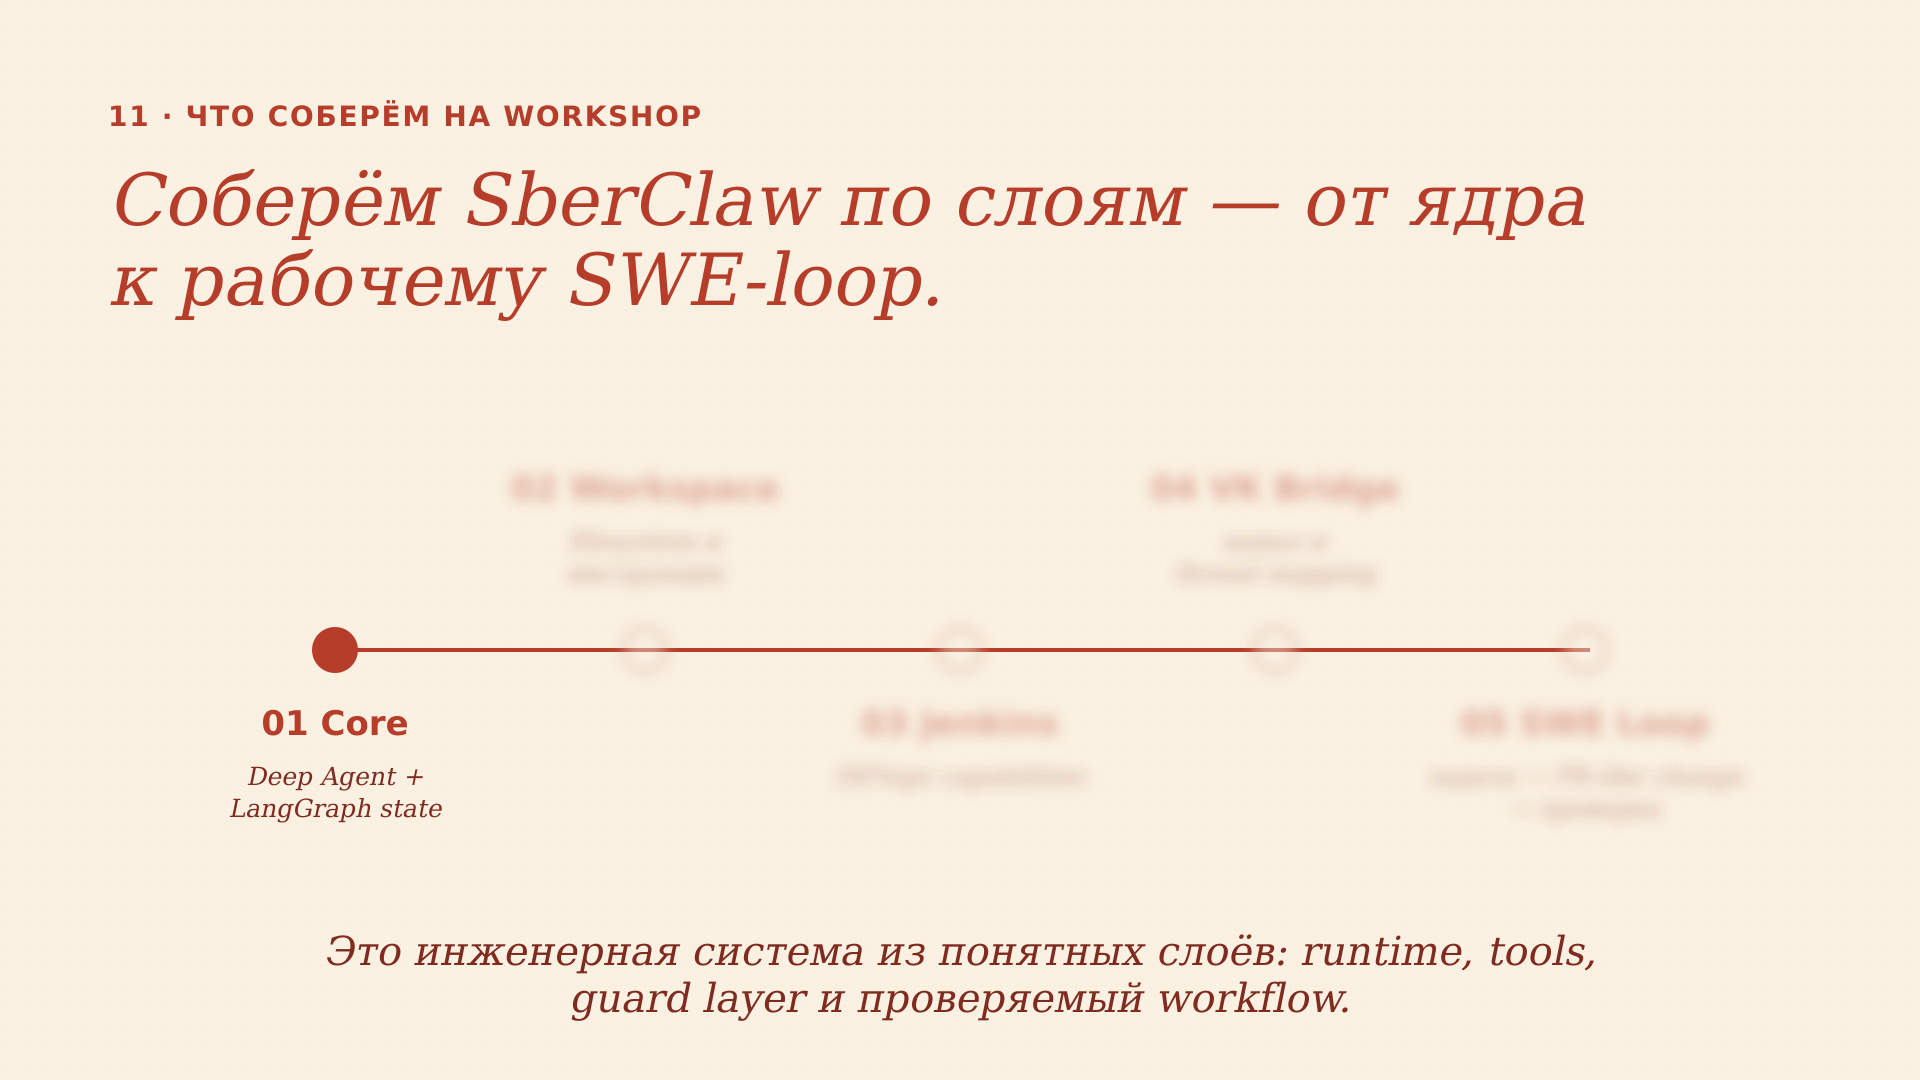

In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd() / 'workshop_notebooks' / 'openclaw_path'):
    if (candidate / 'workshop_utils.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from workshop_utils import REPO_ROOT, print_stage_context, register_graphs, write_text

print_stage_context()
print("pyproject:", REPO_ROOT / "pyproject.toml")

ENTRYPOINT = '''\
from __future__ import annotations

from pathlib import Path

from deepagents import create_deep_agent
from dotenv import load_dotenv

from agents.model_config import workshop_model

REPO_ROOT = Path(__file__).resolve().parents[1]

load_dotenv(REPO_ROOT / ".env")


CORE_PROMPT = """\
You are OpenClaw at stage 01 Core.
Respond in the user's language; default to Russian.

This graph demonstrates only the core Deep Agent harness:
- model;
- LangGraph state;
- message history;
- agent loop;
- no real workspace backend;
- no external tools.

If the user asks about repository files or external systems, explain that this
Core graph cannot inspect the real repository or call external APIs yet. Do not guess.
"""


agent = create_deep_agent(
    model=workshop_model(),
    tools=[],
    system_prompt=CORE_PROMPT,
)
'''

entrypoint = write_text('agents/openclaw_01_core.py', ENTRYPOINT)
config_path = register_graphs({
    'openclaw_01_core': './agents/openclaw_01_core.py:agent'
})

print("Entrypoint:", entrypoint.relative_to(REPO_ROOT))
print("LangGraph config:", config_path.relative_to(REPO_ROOT))

print("User tools:", [])
print("Backend:", None)




### Запрос

```text
Найди файл pyproject.toml и назови имя проекта и три зависимости. Если у тебя нет доступа к файлам, прямо скажи об этом.
```